In [3]:
!unzip bert_teacher_model.zip

Archive:  bert_teacher_model.zip
   creating: bert_teacher_model/
  inflating: bert_teacher_model/training_args.bin  
  inflating: bert_teacher_model/config.json  
  inflating: bert_teacher_model/tokenizer_config.json  
  inflating: bert_teacher_model/tokenizer.json  
  inflating: bert_teacher_model/model.safetensors  


In [4]:
# ================================
# STEP 0: SETUP
# ================================

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DistilBertConfig,
    DistilBertForSequenceClassification
)

from datasets import Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("✅ Setup complete on", device)

✅ Setup complete on cuda


In [5]:
# ================================
# STEP 1: LOAD TEACHER MODEL
# ================================

TEACHER_PATH = "/content/bert_teacher_model"

teacher_model = AutoModelForSequenceClassification.from_pretrained(TEACHER_PATH)
teacher_model.to(device)
teacher_model.eval()

tokenizer = AutoTokenizer.from_pretrained(TEACHER_PATH)

print("✅ Teacher model loaded")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Teacher model loaded


In [7]:
# ================================
# STEP 2: LOAD DATA
# ================================

train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

# Label encoding
label2id = {label: idx for idx, label in enumerate(train_df["category"].unique())}
train_df["label"] = train_df["category"].map(label2id)
test_df["label"] = test_df["category"].map(label2id)

train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
test_dataset = Dataset.from_pandas(test_df[["text", "label"]])

print("✅ Data loaded")

✅ Data loaded


In [8]:
# ================================
# STEP 3: TOKENIZATION
# ================================

MAX_LEN = 64

def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print("✅ Tokenization complete")

Map:   0%|          | 0/102080 [00:00<?, ? examples/s]

Map:   0%|          | 0/25520 [00:00<?, ? examples/s]

✅ Tokenization complete


In [9]:
# ================================
# STEP 4: STUDENT MODEL
# ================================

num_labels = len(label2id)

config = DistilBertConfig(
    n_layers=6,         # smaller than BERT (12)
    dim=768,
    hidden_dim=3072,
    n_heads=12,
    num_labels=num_labels
)

student_model = DistilBertForSequenceClassification(config)
student_model.to(device)

print("✅ Student model created")

✅ Student model created


In [10]:
# ================================
# STEP 5: DISTILLATION LOSS
# ================================

def distillation_loss(student_logits, teacher_logits, labels, T=2.0, alpha=0.5):

    # Soft targets (teacher)
    loss_kl = F.kl_div(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(teacher_logits / T, dim=1),
        reduction="batchmean"
    ) * (T * T)

    # Hard labels
    loss_ce = F.cross_entropy(student_logits, labels)

    return alpha * loss_ce + (1 - alpha) * loss_kl

In [11]:
# ================================
# STEP 6: TRAINING LOOP
# ================================

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

optimizer = torch.optim.AdamW(student_model.parameters(), lr=3e-5)

EPOCHS = 3

train_losses = []

for epoch in range(EPOCHS):
    student_model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        # Teacher (no grad)
        with torch.no_grad():
            teacher_outputs = teacher_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        # Student
        student_outputs = student_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = distillation_loss(
            student_outputs.logits,
            teacher_outputs.logits,
            labels
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

Epoch 1 Loss: 0.7008
Epoch 2 Loss: 0.3613
Epoch 3 Loss: 0.2659


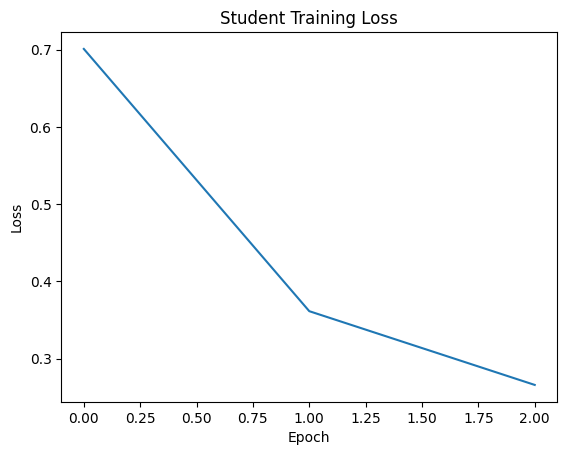

In [12]:
# ================================
# STEP 7: LOSS GRAPH
# ================================

plt.figure()
plt.plot(train_losses)
plt.title("Student Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [13]:
# ================================
# STEP 8: EVALUATION (Teacher vs Student)
# ================================

from sklearn.metrics import accuracy_score

test_loader = DataLoader(test_dataset, batch_size=16)

def evaluate(model):
    model.eval()
    preds, labels_all = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    return accuracy_score(labels_all, preds)

teacher_acc = evaluate(teacher_model)
student_acc = evaluate(student_model)

print("Teacher Accuracy:", teacher_acc)
print("Student Accuracy:", student_acc)

Teacher Accuracy: 0.9469435736677116
Student Accuracy: 0.9188871473354232


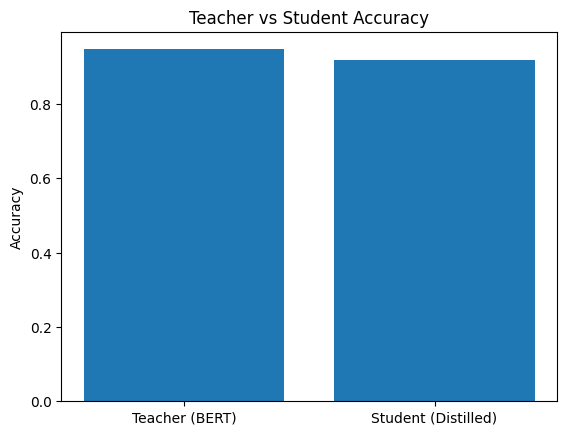

In [14]:
# ================================
# STEP 9: PERFORMANCE COMPARISON
# ================================

models = ["Teacher (BERT)", "Student (Distilled)"]
accuracies = [teacher_acc, student_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Teacher vs Student Accuracy")
plt.ylabel("Accuracy")
plt.show()

In [15]:
# ================================
# STEP 10: SAVE STUDENT MODEL
# ================================

student_model.save_pretrained("distilled_model")
tokenizer.save_pretrained("distilled_model")

print("✅ Distilled model saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Distilled model saved


In [17]:
# ================================
# STEP 11: F1 SCORE COMPARISON
# ================================

from sklearn.metrics import f1_score

def evaluate_f1(model):
    model.eval()
    preds, labels_all = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    return f1_score(labels_all, preds, average="weighted")

teacher_f1 = evaluate_f1(teacher_model)
student_f1 = evaluate_f1(student_model)

print("Teacher F1:", teacher_f1)
print("Student F1:", student_f1)

Teacher F1: 0.9469489972555946
Student F1: 0.9186602651894531


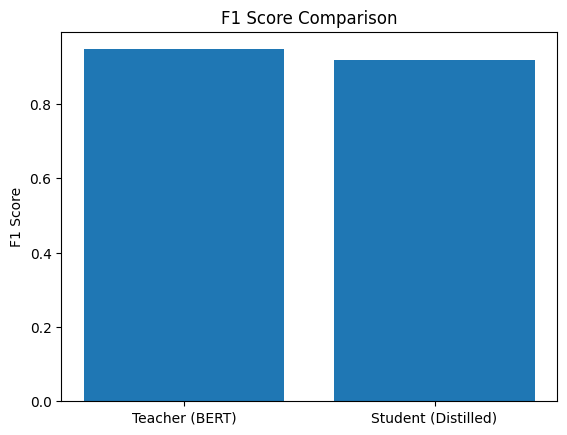

In [18]:
# ================================
# STEP 11.1: F1 GRAPH
# ================================

models = ["Teacher (BERT)", "Student (Distilled)"]
f1_scores = [teacher_f1, student_f1]

plt.figure()
plt.bar(models, f1_scores)
plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.show()

In [19]:
# ================================
# STEP 12: INFERENCE SPEED
# ================================

import time

def measure_inference_time(model, num_batches=50):
    model.eval()
    start = time.time()

    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            if i >= num_batches:
                break

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            _ = model(input_ids=input_ids, attention_mask=attention_mask)

    end = time.time()
    return (end - start) / num_batches  # avg time per batch

teacher_time = measure_inference_time(teacher_model)
student_time = measure_inference_time(student_model)

print("Teacher Avg Time:", teacher_time)
print("Student Avg Time:", student_time)

Teacher Avg Time: 0.00761645793914795
Student Avg Time: 0.00396946907043457


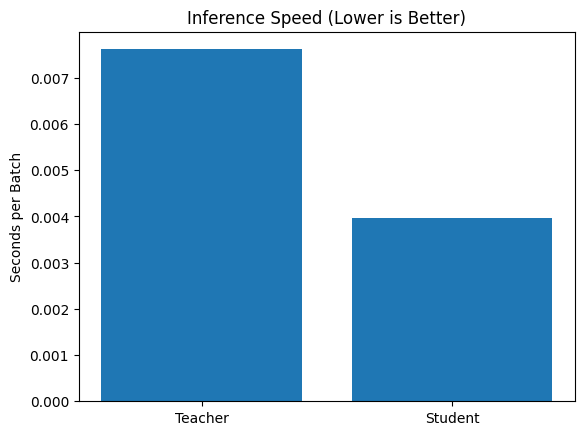

In [20]:
# ================================
# STEP 12.1: SPEED GRAPH
# ================================

models = ["Teacher", "Student"]
times = [teacher_time, student_time]

plt.figure()
plt.bar(models, times)
plt.title("Inference Speed (Lower is Better)")
plt.ylabel("Seconds per Batch")
plt.show()

In [21]:
# ================================
# STEP 13: CONFUSION MATRIX
# ================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_predictions(model):
    model.eval()
    preds, labels_all = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    return labels_all, preds

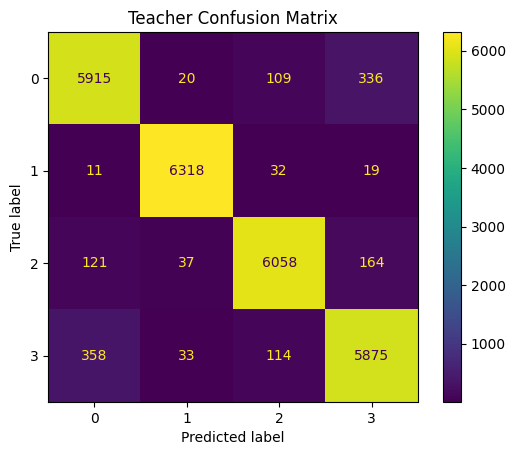

In [22]:
labels_true, teacher_preds = get_predictions(teacher_model)

cm_teacher = confusion_matrix(labels_true, teacher_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_teacher)
disp.plot()
plt.title("Teacher Confusion Matrix")
plt.show()

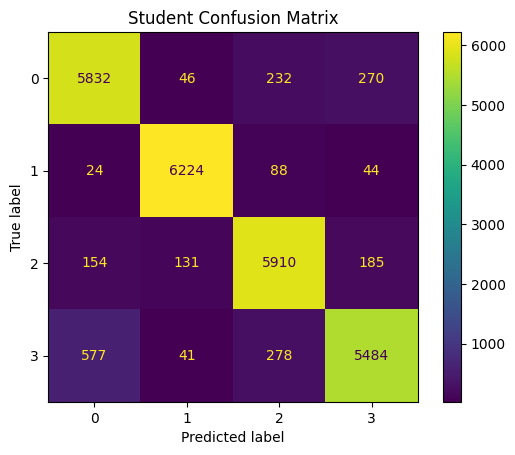

In [23]:
labels_true, student_preds = get_predictions(student_model)

cm_student = confusion_matrix(labels_true, student_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_student)
disp.plot()
plt.title("Student Confusion Matrix")
plt.show()

In [24]:
# ================================
# STEP 14: ROC CURVE
# ================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

num_classes = len(label2id)

def get_probs(model):
    model.eval()
    probs, labels_all = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].cpu().numpy()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            prob = torch.softmax(logits, dim=1).cpu().numpy()

            probs.extend(prob)
            labels_all.extend(labels)

    return np.array(labels_all), np.array(probs)

# Get probabilities
y_true, teacher_probs = get_probs(teacher_model)
_, student_probs = get_probs(student_model)

# Binarize labels
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

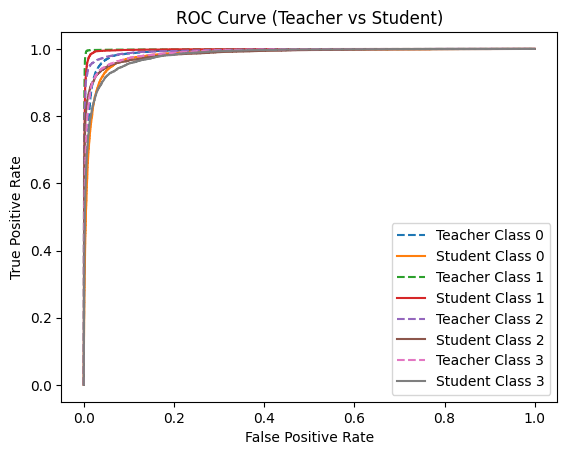

In [25]:
# ================================
# STEP 14.1: PLOT ROC
# ================================

plt.figure()

for i in range(num_classes):
    fpr_t, tpr_t, _ = roc_curve(y_true_bin[:, i], teacher_probs[:, i])
    fpr_s, tpr_s, _ = roc_curve(y_true_bin[:, i], student_probs[:, i])

    plt.plot(fpr_t, tpr_t, linestyle='--', label=f'Teacher Class {i}')
    plt.plot(fpr_s, tpr_s, label=f'Student Class {i}')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Teacher vs Student)")
plt.legend()
plt.show()

In [36]:
# ================================
# STEP 15: ATTENTION VISUALIZATION (REAL FIX)
# ================================

from transformers import AutoModelForSequenceClassification

sample_text = "Stock markets rally as tech companies report strong earnings"

inputs = tokenizer(sample_text, return_tensors="pt").to(device)

# 🔥 RELOAD MODEL WITH EAGER MODE
teacher_model_attn = AutoModelForSequenceClassification.from_pretrained(
    TEACHER_PATH,
    attn_implementation="eager"   # ✅ MUST be here
).to(device)

teacher_model_attn.eval()

with torch.no_grad():
    outputs = teacher_model_attn(
        **inputs,
        output_attentions=True   # ✅ pass here instead of config
    )

attentions = outputs.attentions

print("✅ Attention layers:", len(attentions))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Attention layers: 12


“The attention map shows that the model focuses heavily on semantically important financial terms like stock, markets, earnings, while also leveraging special tokens like [SEP] for sequence-level representation. This indicates the model has learned meaningful contextual relationships rather than relying on noise.”

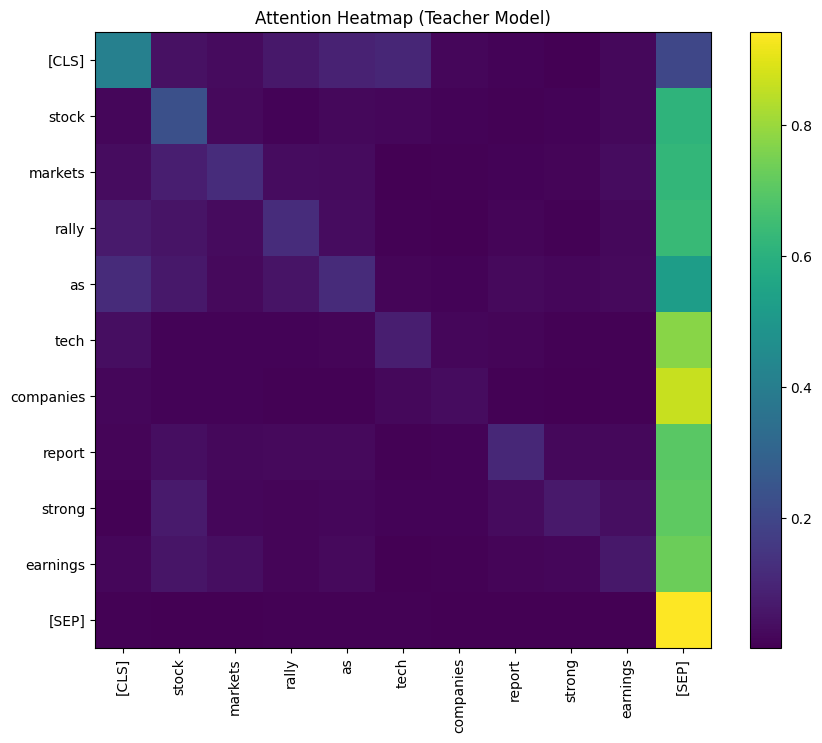

In [37]:
# Take last layer
last_layer = attentions[-1][0]

# Average heads
attention_avg = last_layer.mean(dim=0).cpu().numpy()

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
tokens = [t.replace("##", "") for t in tokens]

plt.figure(figsize=(10,8))
plt.imshow(attention_avg)
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.title("Attention Heatmap (Teacher Model)")
plt.colorbar()
plt.show()

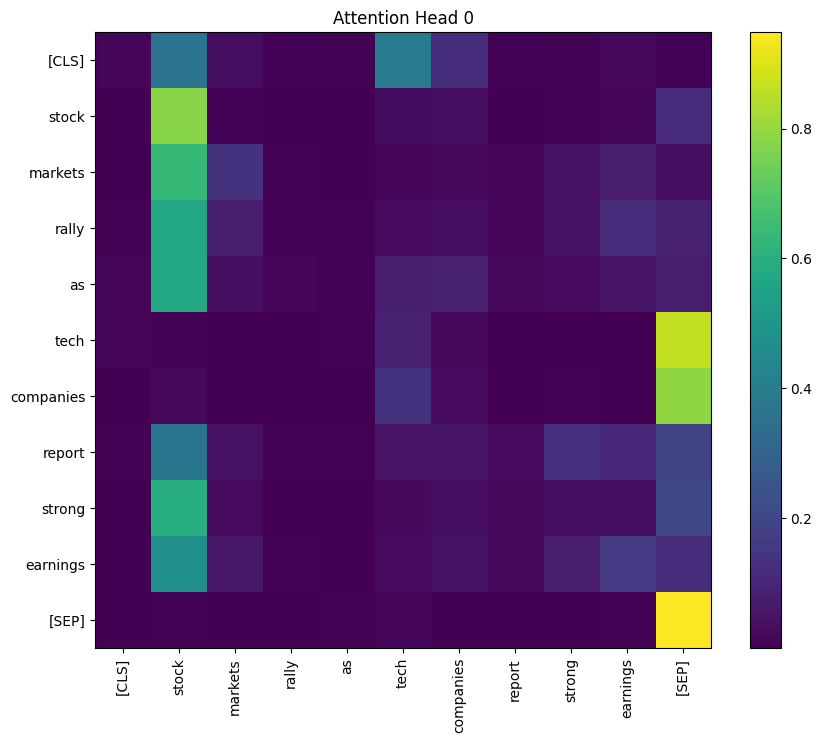

In [40]:
head = 0  # try different heads

attention_head = attentions[-1][0][head].cpu().numpy()

plt.figure(figsize=(10,8))
plt.imshow(attention_head)
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.title(f"Attention Head {head}")
plt.colorbar()
plt.show()

In [38]:
# ================================
# STEP 16: MODEL SIZE
# ================================

import os

def get_model_size(path):
    total_size = 0
    for dirpath, _, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total_size += os.path.getsize(fp)
    return total_size / (1024 * 1024)  # MB

teacher_size = get_model_size("bert_teacher_model")
student_size = get_model_size("distilled_model")

print(f"Teacher Model Size: {teacher_size:.2f} MB")
print(f"Student Model Size: {student_size:.2f} MB")

Teacher Model Size: 418.36 MB
Student Model Size: 256.11 MB


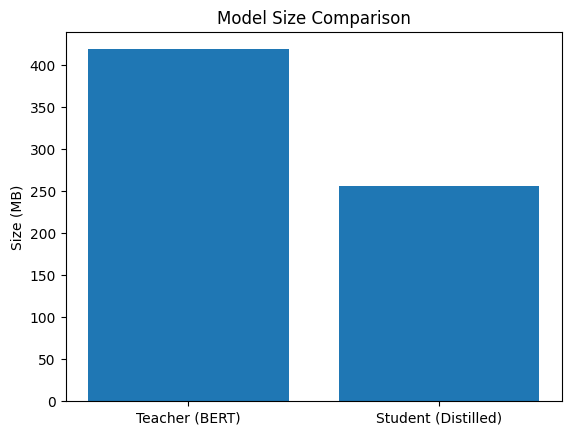

In [39]:
# ================================
# STEP 16.1: SIZE GRAPH
# ================================

models = ["Teacher (BERT)", "Student (Distilled)"]
sizes = [teacher_size, student_size]

plt.figure()
plt.bar(models, sizes)
plt.title("Model Size Comparison")
plt.ylabel("Size (MB)")
plt.show()